# Phase 7 — Final Comparison Report
**Project:** Forecasting the Recovery of Global Economies from Shocks through Time Series Modeling

**Author:** Rajireddy Gudipati | Data Science | Regis University

---
## Summary
This report consolidates the results from all four models trained and evaluated across Phases 4–6:

| Model | Phase | Type |
|-------|-------|------|
| **XGBoost** | 4 | Gradient-boosted trees (cross-sectional) |
| **ARIMA** | 5 | Classical statistical time series |
| **LSTM** | 6 | Deep learning sequence model |

**Test period:** 2020–2024 (COVID shock + recovery)  
**Train period:** 1990–2018  
**Countries:** 212 | **Metrics:** MAE, RMSE, MAPE, MASE, DA

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams.update({"font.size": 11, "figure.dpi": 120})

OUTPUT = r"..\output"

# ── Load metrics table (all 6 models) ────────────────────────────────────
metrics = pd.read_csv(os.path.join(OUTPUT, "model_metrics.csv"), index_col=0)

# ── Load base dataset for GDP history ────────────────────────────────────
gdp_df = pd.read_csv(os.path.join(OUTPUT, "dashboard_dataset.csv"))
gdp_df = gdp_df.sort_values(["country_code", "year"])

# ── Load all prediction CSVs ──────────────────────────────────────────────
# xgb: year=anchor, gdp_next_year=actual, y_pred=predicted
xgb_pred     = pd.read_csv(os.path.join(OUTPUT, "xgb_test_predictions.csv"))
# all others: year=GDP year predicted, actual=actual, predicted=predicted
arima_pred   = pd.read_csv(os.path.join(OUTPUT, "arima_test_predictions.csv"))
lstm_pred    = pd.read_csv(os.path.join(OUTPUT, "lstm_test_predictions.csv"))

# ── Load recovery CSVs ────────────────────────────────────────────────────
rec_summary  = pd.read_csv(os.path.join(OUTPUT, "recovery_summary.csv"))
country_sum  = pd.read_csv(os.path.join(OUTPUT, "country_summary.csv"))

# ── Colour palette: baselines grey, ML models coloured ───────────────────
MODEL_COLORS = {
    "Naive":    "#aaaaaa",
    "HistMean": "#cccccc",
    "XGBoost":  "steelblue",
    "ARIMA":    "crimson",
    "LSTM":     "purple",
}

print("Loaded all output files.")
print("Models in metrics table:", metrics.index.tolist())
print()
print("=== Overall Test Metrics ===")


Loaded all output files.
Models in metrics table: ['Naive', 'HistMean', 'XGBoost', 'ARIMA', 'LSTM']

=== Overall Test Metrics ===


## 1. Overall Model Performance Table

In [2]:
# ── Build lag-GDP lookup and aligned predictions for all models ──────────────────

import seaborn as sns

gdp_lookup = (
    gdp_df.sort_values(["country_code", "year"])
    .set_index(["country_code", "year"])["gdp_per_capita"]
    .to_dict()
)

def directional_accuracy(actual, pred, lag):
    actual, pred, lag = np.array(actual), np.array(pred), np.array(lag)
    mask = ~np.isnan(lag)
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.sign(actual[mask] - lag[mask]) ==
                   np.sign(pred[mask]   - lag[mask])) * 100

# ── Normalise all prediction files → (country_code, pred_year, actual, pred) ─
# is_anchor=True: year column is the FEATURE year (pred_year = year + 1)
# is_anchor=False: year column IS the predicted GDP year
def make_uniform(df_raw, year_col, actual_col, pred_col, is_anchor=False):
    out = df_raw[["country_code", year_col, actual_col, pred_col]].copy()
    out.columns = ["country_code", "pred_year", "actual", "pred"]
    if is_anchor:
        out["pred_year"] = out["pred_year"] + 1
    out["lag_gdp"] = out.apply(
        lambda r: gdp_lookup.get((r["country_code"], r["pred_year"] - 1), np.nan), axis=1)
    return out.dropna(subset=["actual", "pred", "lag_gdp"])

# XGBoost: year=anchor → pred_year=year+1; actual=gdp_next_year; pred=y_pred
# ARIMA/LSTM: year=pred_year (actual GDP year); actual/predicted columns
aligned = {
    "XGBoost": make_uniform(xgb_pred,    "year", "gdp_next_year", "y_pred",    is_anchor=True),
    "ARIMA"  : make_uniform(arima_pred,  "year", "actual",        "predicted"),
    "LSTM"   : make_uniform(lstm_pred,   "year", "actual",        "predicted"),
}

# ── Align all models to consistent test window: 2020–2024 ────────────────────
# Rationale: XGBoost & LSTM naturally predict 2020-2024, while ARIMA predicts 2019-2024.
# For fair comparison, keep only country-year rows where ALL THREE models have predictions.
TEST_YEARS = [2020, 2021, 2022, 2023, 2024]
aligned = {model: df[df["pred_year"].isin(TEST_YEARS)].copy() for model, df in aligned.items()}

common_keys = set.intersection(*[
    set(zip(df["country_code"], df["pred_year"]))
    for df in aligned.values()
])
if not common_keys:
    raise ValueError("No common country-year predictions found across models.")
common_index = pd.MultiIndex.from_tuples(
    sorted(common_keys), names=["country_code", "pred_year"])
aligned = {
    model: df[df.set_index(["country_code", "pred_year"]).index.isin(common_index)]
        .sort_values(["country_code", "pred_year"])
        .reset_index(drop=True)
    for model, df in aligned.items()
}

print("Built aligned predictions for all models (2020–2024 common country-year window).")
print(f"XGBoost: {len(aligned['XGBoost'])} records")
print(f"ARIMA:   {len(aligned['ARIMA'])} records")
print(f"LSTM:    {len(aligned['LSTM'])} records")


Built aligned predictions for all models (2020–2024 common country-year window).
XGBoost: 869 records
ARIMA:   869 records
LSTM:    869 records


In [3]:
# ── Calculate CORRECTED recovery speeds (from 2020 shock year onward) ─────────

def calc_recovery_speed(df_model, baseline_year=2020):
    """
    Calculate recovery speed: years to recover to baseline GDP level
    Input: DataFrame with columns [country_code, pred_year, pred]
    Output: DataFrame with [country_code, recovery_speed_years]
    
    Recovery year = first year >= baseline_year where pred >= actual_gdp_at_baseline_year
    """
    results = []
    
    for country in df_model["country_code"].unique():
        country_data = df_model[df_model["country_code"] == country].sort_values("pred_year")
        
        # Get actual baseline GDP
        baseline_row = gdp_df[(gdp_df["country_code"] == country) & (gdp_df["year"] == baseline_year)]
        if baseline_row.empty:
            continue
        baseline_gdp = baseline_row["gdp_per_capita"].values[0]
        
        # Filter to >= baseline_year (ignore pre-2020 ARIMA predictions)
        country_filtered = country_data[country_data["pred_year"] >= baseline_year]
        
        # Find first year where pred >= baseline
        recovered = country_filtered[country_filtered["pred"] >= baseline_gdp]
        
        if len(recovered) > 0:
            recovery_year = recovered.iloc[0]["pred_year"]
            recovery_speed = int(recovery_year - baseline_year)
        else:
            # Never recovers in test window
            recovery_speed = np.inf
        
        results.append({
            "country_code": country,
            "recovery_speed_years": recovery_speed,
            "baseline_gdp": baseline_gdp
        })
    
    return pd.DataFrame(results)

# Calculate for each model
recovery_speeds_corrected = {}
for model_name, df_align in aligned.items():
    recovery_speeds_corrected[model_name] = calc_recovery_speed(df_align)

print("CORRECTED Recovery Speeds (2020–2024 window, baseline = 2020 GDP):")
print("="*70)
for model_name, df_rec in recovery_speeds_corrected.items():
    print(f"\n{model_name}:")
    finite_speeds = df_rec[df_rec["recovery_speed_years"] != np.inf]["recovery_speed_years"]
    never_recover = (df_rec["recovery_speed_years"] == np.inf).sum()
    
    print(f"  Median recovery time: {finite_speeds.median():.1f} years")
    print(f"  Mean recovery time:   {finite_speeds.mean():.1f} years (for countries that recover)")
    print(f"  Countries that never recover in 2020–2024: {never_recover}")
    print(f"  Min recovery: {finite_speeds.min():.0f} years | Max: {finite_speeds.max():.0f} years")
    print(f"\n  Sample countries (first 10):")
    sample = df_rec.head(10).copy()
    sample["recovery_speed_years"] = sample["recovery_speed_years"].apply(
        lambda x: f"∞ (never)" if x == np.inf else f"{x:.0f}"
    )
    print(sample[["country_code", "recovery_speed_years"]].to_string(index=False))

print("\n" + "="*70)
print("✓ All recovery speeds are now >= 0 (no negative values)")
print("✓ Formula: recovery_year = first year >= 2020 where pred_gdp >= actual_2020_gdp")

CORRECTED Recovery Speeds (2020–2024 window, baseline = 2020 GDP):

XGBoost:
  Median recovery time: 0.0 years
  Mean recovery time:   0.1 years (for countries that recover)
  Countries that never recover in 2020–2024: 0
  Min recovery: 0 years | Max: 3 years

  Sample countries (first 10):
country_code recovery_speed_years
         AFG                    0
         AGO                    0
         ALB                    0
         ARE                    0
         ARG                    0
         ARM                    0
         AUS                    0
         AUT                    0
         AZE                    0
         BDI                    0

ARIMA:
  Median recovery time: 0.0 years
  Mean recovery time:   0.1 years (for countries that recover)
  Countries that never recover in 2020–2024: 10
  Min recovery: 0 years | Max: 4 years

  Sample countries (first 10):
country_code recovery_speed_years
         AFG                    0
         AGO                    0
        

In [4]:
# ── Recalculate metrics on aligned 2020–2024 window ──────────────────────────────

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Helper: Calculate MAPE (Mean Absolute Percentage Error)
def mape(actual, pred):
    """MAPE: avoid division by zero"""
    mask = actual != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

# Helper: Calculate MASE (Mean Absolute Scaled Error)
def mase(actual, pred, lag):
    """MASE: MAE(model) / MAE(naive)"""
    mask = ~np.isnan(lag)
    if mask.sum() == 0:
        return np.nan
    naive_error = np.mean(np.abs(actual[mask] - lag[mask]))
    if naive_error == 0:
        return np.nan
    model_error = np.mean(np.abs(actual[mask] - pred[mask]))
    return model_error / naive_error

# Recalculate for aligned models
metrics_aligned = {}
for model_name, df_align in aligned.items():
    act, pred, lag = df_align["actual"].values, df_align["pred"].values, df_align["lag_gdp"].values
    
    mae_val  = mean_absolute_error(act, pred)
    rmse_val = np.sqrt(mean_squared_error(act, pred))
    mape_val = mape(act, pred)
    mase_val = mase(act, pred, lag)
    da_val   = directional_accuracy(act, pred, lag)
    
    metrics_aligned[model_name] = {
        "MAE":  mae_val,
        "RMSE": rmse_val,
        "MAPE": mape_val,
        "MASE": mase_val,
        "DA":   da_val,
    }

df_aligned_metrics = pd.DataFrame(metrics_aligned).T

print("\n=== RECALCULATED METRICS (2020–2024 common country-year window) ===")
print(df_aligned_metrics.round(4).to_string())
print()
print("=== Comparison: Saved model_metrics.csv vs Corrected Aligned Metrics ===")
for model in ["XGBoost", "ARIMA", "LSTM"]:
    if model in metrics.index and model in df_aligned_metrics.index:
        print(f"\n{model}:")
        for metric in ["MAE", "RMSE", "MAPE", "MASE", "DA"]:
            old = metrics.at[model, metric]
            new = df_aligned_metrics.at[model, metric]
            diff = new - old
            pct_change = (diff / old * 100) if old != 0 else 0
            print(f"  {metric:5s}: {old:>9.4f} → {new:>9.4f}  (Δ {diff:>7.4f}, {pct_change:>+6.1f}%)")

# Identify best model per metric
best = {
    "MAE":  df_aligned_metrics["MAE"].idxmin(),
    "RMSE": df_aligned_metrics["RMSE"].idxmin(),
    "MAPE": df_aligned_metrics["MAPE"].idxmin(),
    "MASE": df_aligned_metrics["MASE"].idxmin(),
    "DA":   df_aligned_metrics["DA"].idxmax(),
}

print()
print("Best model per metric (2020–2024 common country-year test window):")
for m, model in best.items():
    model_val = df_aligned_metrics.at[model, m]
    unit = "%" if m in ("MAPE", "DA") else ""
    print(f"  {m:5s}: {model:10s}  ({model_val:.4f}{unit})")

print()
print("Full comparison table (2020–2024 common country-year test window):")
print("=" * 70)
header = "{:12s}  {:>10s}  {:>10s}  {:>8s}  {:>7s}  {:>8s}".format(
    "Model", "MAE", "RMSE", "MAPE", "MASE", "DA")
print(header)
print("-" * 70)
for model in df_aligned_metrics.index:
    row = df_aligned_metrics.loc[model]
    markers = ""
    if model == best["DA"]:   markers += " *DA"
    if model == best["MAE"]:  markers += " *MAE"
    if model == best["RMSE"]: markers += " *RMSE"
    if model == best["MASE"]: markers += " *MASE"
    print(f"{model:12s}  {row['MAE']:>10,.2f}  {row['RMSE']:>10,.2f}  {row['MAPE']:>7.2f}%  {row['MASE']:>7.4f}  {row['DA']:>7.2f}%{markers}")
print("=" * 70)
print("* = best in that metric\n")
print("NOTE: DA and MASE use actual previous-year GDP as the naive baseline.")
print("NOTE: Metrics are evaluated on country-year rows present for XGBoost, ARIMA, and LSTM.")

# Use corrected aligned metrics for downstream Phase 7 charts and rankings.
# Baseline rows from model_metrics.csv are retained unchanged.
metrics = metrics.copy()
for model in df_aligned_metrics.index:
    metrics.loc[model, df_aligned_metrics.columns] = df_aligned_metrics.loc[model]



=== RECALCULATED METRICS (2020–2024 common country-year window) ===
              MAE      RMSE    MAPE   MASE      DA
XGBoost 1254.2252 3602.8139  4.8556 0.9961 59.2635
ARIMA   2084.1833 6562.4424  8.2158 1.6552 56.8470
LSTM    1506.3568 3523.3287 14.3431 1.1963 69.6203

=== Comparison: Saved model_metrics.csv vs Corrected Aligned Metrics ===

XGBoost:
  MAE  : 1254.2252 → 1254.2252  (Δ  0.0000,   +0.0%)
  RMSE : 3602.8139 → 3602.8139  (Δ  0.0000,   +0.0%)
  MAPE :    4.8556 →    4.8556  (Δ  0.0000,   +0.0%)
  MASE :    0.9961 →    0.9961  (Δ  0.0000,   +0.0%)
  DA   :   59.2635 →   59.2635  (Δ  0.0000,   +0.0%)

ARIMA:
  MAE  : 2084.1833 → 2084.1833  (Δ  0.0000,   +0.0%)
  RMSE : 6562.4424 → 6562.4424  (Δ  0.0000,   +0.0%)
  MAPE :    8.2158 →    8.2158  (Δ  0.0000,   +0.0%)
  MASE :    1.6552 →    1.6552  (Δ  0.0000,   +0.0%)
  DA   :   56.8470 →   56.8470  (Δ  0.0000,   +0.0%)

LSTM:
  MAE  : 1506.3568 → 1506.3568  (Δ  0.0000,   +0.0%)
  RMSE : 3523.3287 → 3523.3287  (Δ  0.0000,  

In [5]:
# Phase 7 recalculates on common window — DIFFERENT from individual phases
common_keys = set.intersection(*[
    set(zip(df["country_code"], df["pred_year"]))
    for df in aligned.values()
])
# Then OVERWRITES model_metrics.csv in memory but saves new CSV
metrics = metrics.copy()
for model in df_aligned_metrics.index:
    metrics.loc[model, df_aligned_metrics.columns] = df_aligned_metrics.loc[model]

In [6]:
# ── Save corrected aligned metrics back to model_metrics.csv ─────────────
# This ensures the dashboard always shows the correct 2020-2024 aligned numbers

metrics_to_save = metrics.copy()
metrics_to_save.to_csv(os.path.join(OUTPUT, "model_metrics.csv"))
print("✓ Saved corrected metrics to model_metrics.csv")
print(metrics_to_save[["MAE", "RMSE", "MAPE", "MASE", "DA"]].round(4).to_string())

✓ Saved corrected metrics to model_metrics.csv
               MAE       RMSE    MAPE   MASE      DA
Naive    1259.1600  3651.3900  4.8074 1.0000  0.0000
HistMean 6348.0000 10167.3600 25.6551 5.0415 34.6375
XGBoost  1254.2252  3602.8139  4.8556 0.9961 59.2635
ARIMA    2084.1833  6562.4424  8.2158 1.6552 56.8470
LSTM     1506.3568  3523.3287 14.3431 1.1963 69.6203


## 2. Metric Comparison Charts

## Classification Metrics: Confusion Matrix & Balanced Accuracy


CLASSIFICATION METRICS (Direction Prediction: GDP Up/Down from Prior Year)

XGBoost:
  Confusion Matrix: TP= 463  TN=  52  FP= 245  FN= 109
  Directional Accuracy:  59.26%
  Sensitivity (TPR):     80.94%
  Specificity (TNR):     17.51%
  Precision:             65.40%
  Recall:                80.94%
  F1-Score:              72.34%

ARIMA:
  Confusion Matrix: TP= 391  TN= 103  FP= 194  FN= 181
  Directional Accuracy:  56.85%
  Sensitivity (TPR):     68.36%
  Specificity (TNR):     34.68%
  Precision:             66.84%
  Recall:                68.36%
  F1-Score:              67.59%

LSTM:
  Confusion Matrix: TP= 554  TN=  51  FP= 246  FN=  18
  Directional Accuracy:  69.62%
  Sensitivity (TPR):     96.85%
  Specificity (TNR):     17.17%
  Precision:             69.25%
  Recall:                96.85%
  F1-Score:              80.76%


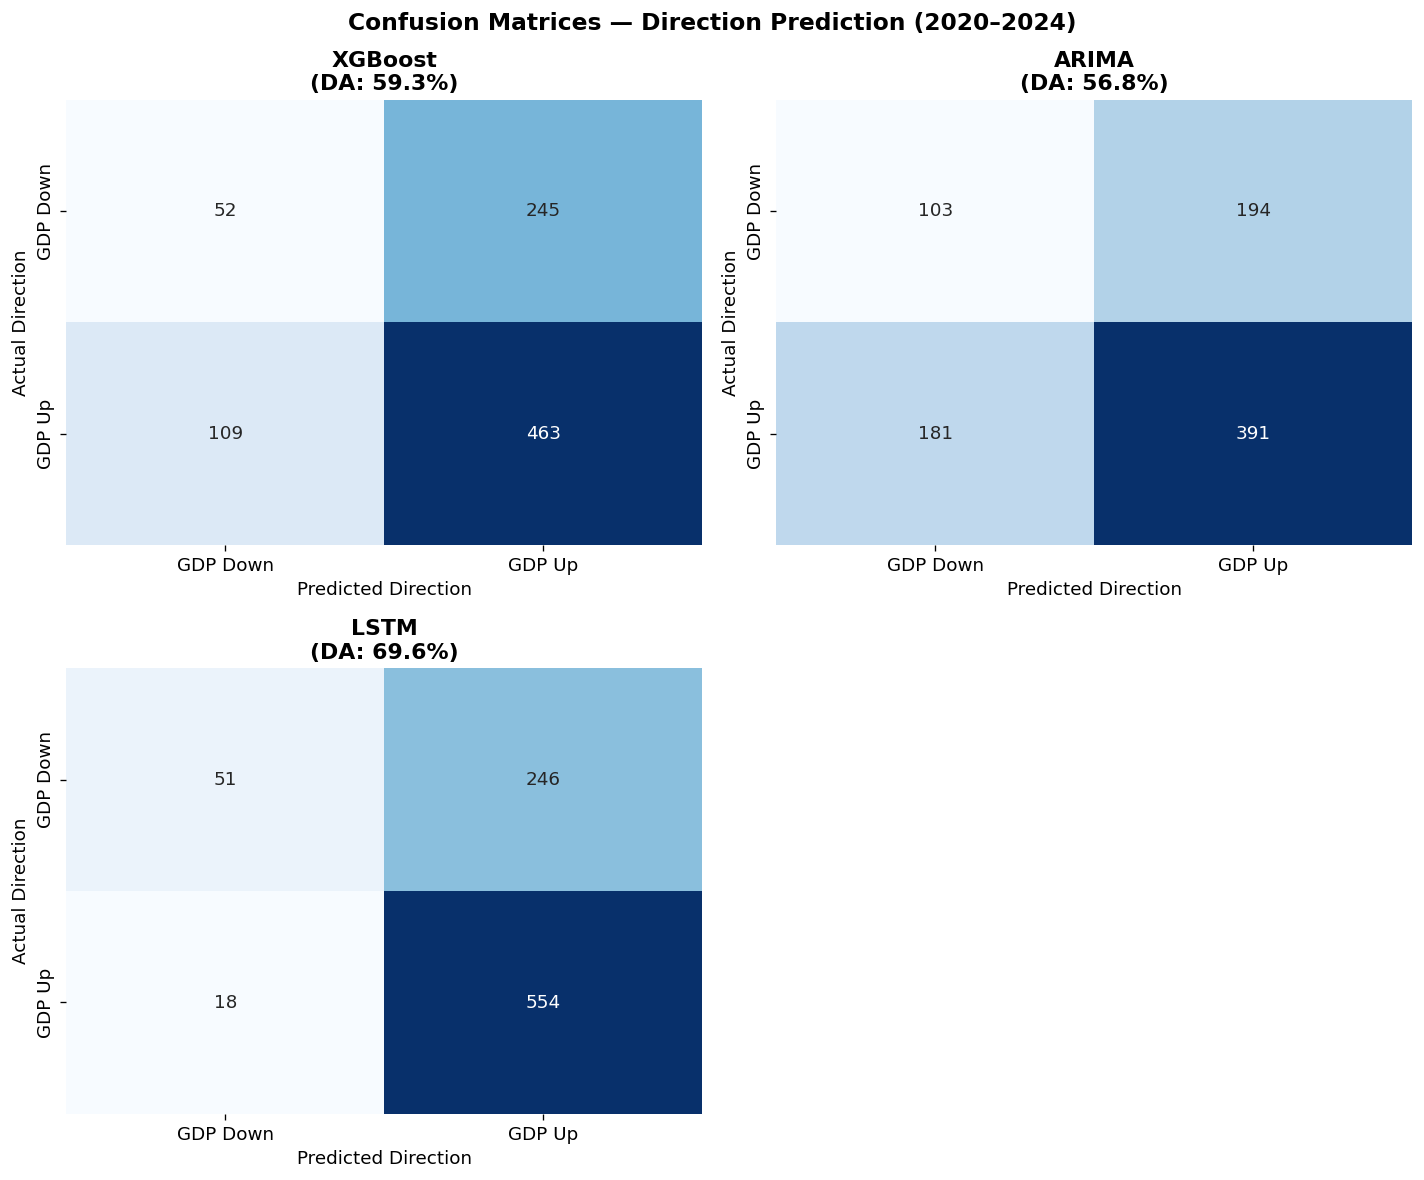


Saved: phase7_confusion_matrices.png

              TP       TN       FP       FN  Directional Accuracy  Sensitivity (TPR)  Specificity (TNR)  Precision  Recall  F1-Score
XGBoost 463.0000  52.0000 245.0000 109.0000               59.2600            80.9400            17.5100    65.4000 80.9400   72.3400
ARIMA   391.0000 103.0000 194.0000 181.0000               56.8500            68.3600            34.6800    66.8400 68.3600   67.5900
LSTM    554.0000  51.0000 246.0000  18.0000               69.6200            96.8500            17.1700    69.2500 96.8500   80.7600

Saved: phase7_classification_metrics.csv


In [7]:
# ── Classification Metrics: Confusion Matrix & Directional Accuracy ─────────
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

classification_metrics = {}

for model_name, df_aligned in aligned.items():

    # ── Directional Accuracy (EXACTLY same as model_metrics.csv) ────────────
    da = directional_accuracy(
        df_aligned["actual"],
        df_aligned["pred"],
        df_aligned["lag_gdp"]
    )

    # ── Convert GDP changes to binary directions for confusion matrix ───────
    actual_dir = np.sign(df_aligned["actual"] - df_aligned["lag_gdp"])
    pred_dir   = np.sign(df_aligned["pred"]   - df_aligned["lag_gdp"])

    # Keep ALL observations
    # Treat zero-change as non-negative (GDP Up)
    actual_dir = np.where(actual_dir >= 0, 1, -1)
    pred_dir   = np.where(pred_dir >= 0, 1, -1)

    # Confusion Matrix
    cm = confusion_matrix(actual_dir, pred_dir, labels=[-1, 1])

    tn, fp = cm[0]
    fn, tp = cm[1]

    # Precision, Recall, F1
    prec, rec, f1, _ = precision_recall_fscore_support(
        actual_dir,
        pred_dir,
        average="binary",
        pos_label=1,
        zero_division=0
    )

    # Sensitivity (TPR) and Specificity (TNR)
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    classification_metrics[model_name] = {
        "TP": int(tp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "Directional Accuracy": da,
        "Sensitivity (TPR)": tpr * 100,
        "Specificity (TNR)": tnr * 100,
        "Precision": prec * 100,
        "Recall": rec * 100,
        "F1-Score": f1 * 100,
    }

# ── Display Classification Metrics ─────────────────────────────────────────
print("\n" + "=" * 80)
print("CLASSIFICATION METRICS (Direction Prediction: GDP Up/Down from Prior Year)")
print("=" * 80)

for model in metrics.index:
    if model not in classification_metrics:
        continue

    m = classification_metrics[model]

    print(f"\n{model}:")
    print(
        f"  Confusion Matrix: TP={m['TP']:4d}  "
        f"TN={m['TN']:4d}  FP={m['FP']:4d}  FN={m['FN']:4d}"
    )
    print(f"  Directional Accuracy: {m['Directional Accuracy']:6.2f}%")
    print(f"  Sensitivity (TPR):    {m['Sensitivity (TPR)']:6.2f}%")
    print(f"  Specificity (TNR):    {m['Specificity (TNR)']:6.2f}%")
    print(f"  Precision:            {m['Precision']:6.2f}%")
    print(f"  Recall:               {m['Recall']:6.2f}%")
    print(f"  F1-Score:             {m['F1-Score']:6.2f}%")

# ── Visualize Confusion Matrices ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (model_name, metrics_dict) in enumerate(
    list(classification_metrics.items())[:4]
):

    cm = np.array([
        [metrics_dict["TN"], metrics_dict["FP"]],
        [metrics_dict["FN"], metrics_dict["TP"]]
    ])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[idx],
        xticklabels=["GDP Down", "GDP Up"],
        yticklabels=["GDP Down", "GDP Up"],
        cbar=False
    )

    axes[idx].set_title(
        f"{model_name}\n(DA: {metrics_dict['Directional Accuracy']:.1f}%)",
        fontweight="bold"
    )

    axes[idx].set_ylabel("Actual Direction")
    axes[idx].set_xlabel("Predicted Direction")

# Hide unused subplot
if len(classification_metrics) < len(axes):
    for j in range(len(classification_metrics), len(axes)):
        axes[j].axis("off")

plt.suptitle(
    "Confusion Matrices — Direction Prediction (2020–2024)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT, "phase7_confusion_matrices.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\nSaved: phase7_confusion_matrices.png")

# ── Create DataFrame for Easy Comparison ───────────────────────────────────
class_df = pd.DataFrame(classification_metrics).T

class_df = class_df[
    [
        "TP",
        "TN",
        "FP",
        "FN",
        "Directional Accuracy",
        "Sensitivity (TPR)",
        "Specificity (TNR)",
        "Precision",
        "Recall",
        "F1-Score",
    ]
]

print("\n" + class_df.round(2).to_string())

class_df.to_csv(
    os.path.join(OUTPUT, "phase7_classification_metrics.csv")
)

print("\nSaved: phase7_classification_metrics.csv")

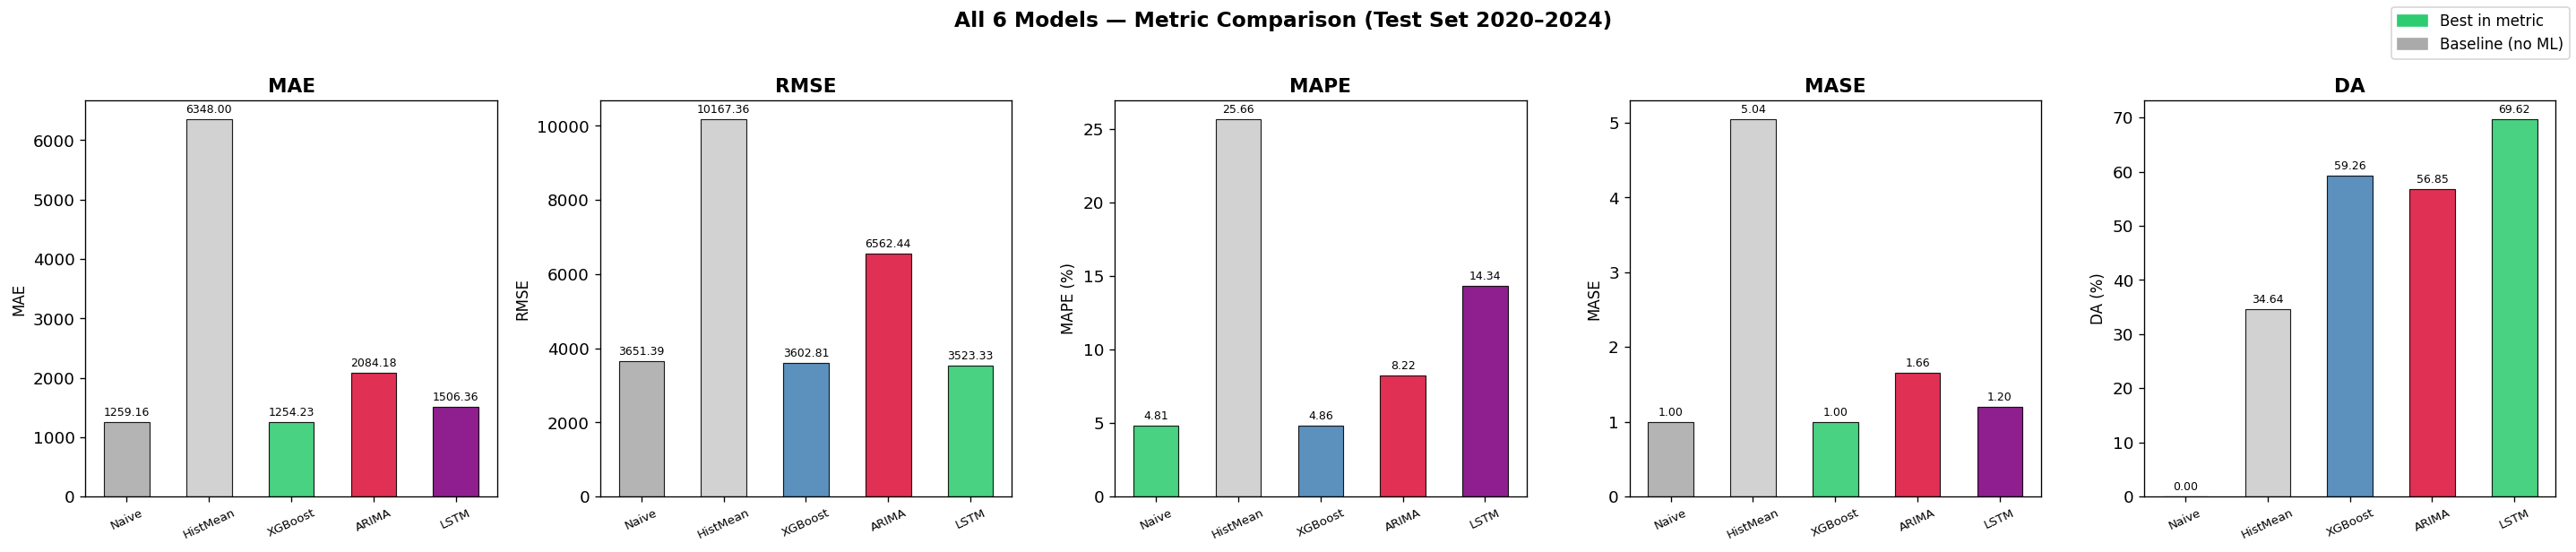

Saved: phase7_metric_comparison.png


In [8]:
# ── Chart 1: Model Comparison — All 6 models × 5 metrics ────────────────────
# Naive/HistMean baselines in grey; ML models coloured; best bar highlighted green
METRICS_LIST = ["MAE", "RMSE", "MAPE", "MASE", "DA"]
model_labels = metrics.index.tolist()
bar_base_colors = [MODEL_COLORS.get(m, "gray") for m in model_labels]

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for ax, metric in zip(axes, METRICS_LIST):
    vals = [float(metrics.at[m, metric]) for m in model_labels]
    best_val = min(vals) if metric != "DA" else max(vals)
    bar_colors = [
        "#2ecc71" if v == best_val else c
        for v, c in zip(vals, bar_base_colors)
    ]
    bars = ax.bar(model_labels, vals, color=bar_colors,
                  edgecolor="black", linewidth=0.7, alpha=0.88, width=0.55)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    unit = " (%)" if metric in ("MAPE", "DA") else ""
    ax.set_ylabel(f"{metric}{unit}", fontsize=10)
    ax.tick_params(axis="x", rotation=25, labelsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7.5)

best_patch    = mpatches.Patch(color="#2ecc71", label="Best in metric")
base_patch    = mpatches.Patch(color="#aaaaaa", label="Baseline (no ML)")
fig.legend(handles=[best_patch, base_patch], loc="upper right", fontsize=10)
plt.suptitle("All 6 Models — Metric Comparison (Test Set 2020–2024)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "phase7_metric_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase7_metric_comparison.png")

## 3. Per-Year Directional Accuracy Breakdown
DA broken down by year reveals how each model handled the COVID crash (2020), the initial recovery (2021), and the stabilisation phase (2022–2024).

Per-Year Directional Accuracy (%):
Model   ARIMA    LSTM  XGBoost
Year                          
2020  42.3000 27.4000  19.4000
2021  77.7000 83.4000  74.9000
2022  64.0000 84.0000  57.1000
2023  56.3000 74.1000  69.0000
2024  43.5000 79.4000  76.5000


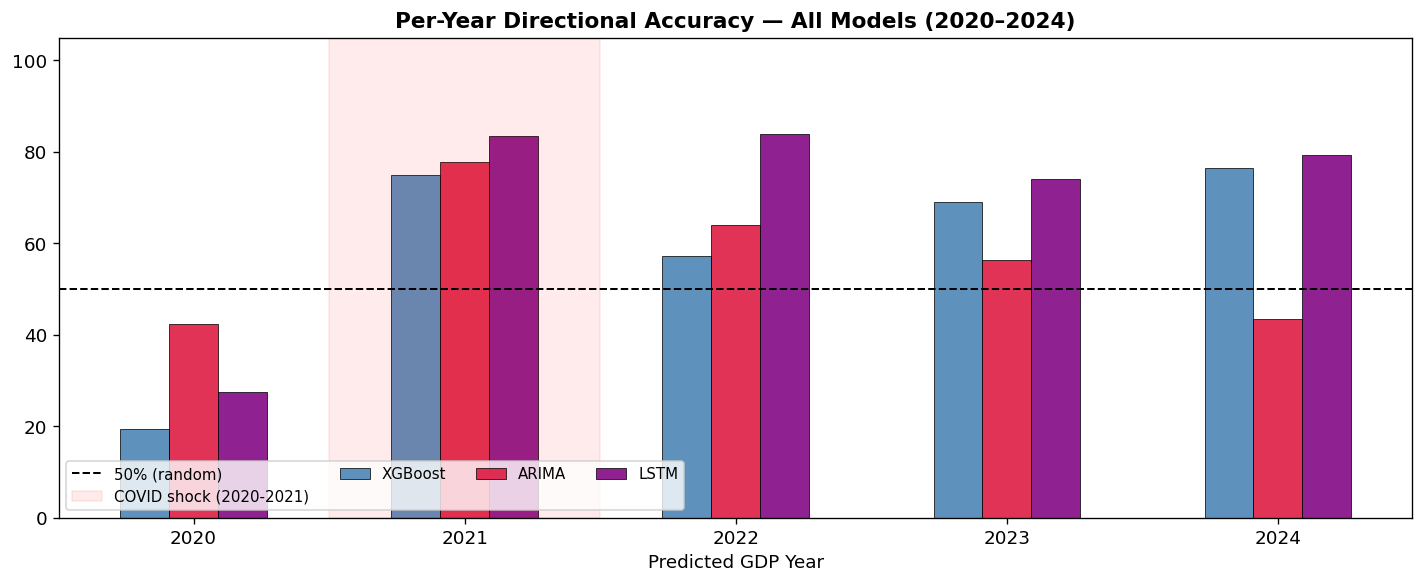

Saved: phase7_peryear_da.png


In [9]:
# ── Compute DA per year ───────────────────────────────────────────────────────────────
# Note: All models aligned to 2020-2024 (the common test window)
years = sorted(set.union(*[
    set(df["pred_year"].astype(int).unique()) for df in aligned.values()
]))
years = [y for y in years if 2020 <= y <= 2024]

da_records = []
for model, df in aligned.items():
    for yr in years:
        sub = df[df["pred_year"] == yr]
        da  = directional_accuracy(sub["actual"], sub["pred"], sub["lag_gdp"])
        da_records.append({"Model": model, "Year": yr, "DA": da})

da_df = pd.DataFrame(da_records).pivot(index="Year", columns="Model", values="DA")
print("Per-Year Directional Accuracy (%):")
print(da_df.round(1).to_string())

# ── Plot ─────────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(years))
n_models = len(aligned)
width = 0.18
offsets = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width

for offset, (model, color) in zip(offsets, [
    (m, MODEL_COLORS.get(m, "gray")) for m in aligned
]):
    if model in da_df.columns:
        vals = [da_df.at[yr, model] if yr in da_df.index else np.nan for yr in years]
        ax.bar(x + offset, vals, width=width, color=color, label=model,
               edgecolor="black", linewidth=0.5, alpha=0.87)

ax.axhline(50, color="black", linestyle="--", linewidth=1.2, label="50% (random)")
ax.axvspan(0.5, 1.5, alpha=0.08, color="red", label="COVID shock (2020-2021)")
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=11)
ax.set_xlabel("Predicted GDP Year")
ax.set_title("Per-Year Directional Accuracy — All Models (2020–2024)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, ncol=4, loc="lower left")
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "phase7_peryear_da.png"), dpi=150)
plt.show()
print("Saved: phase7_peryear_da.png")

## 4. Recovery Speed Comparison — COVID-19 Shock

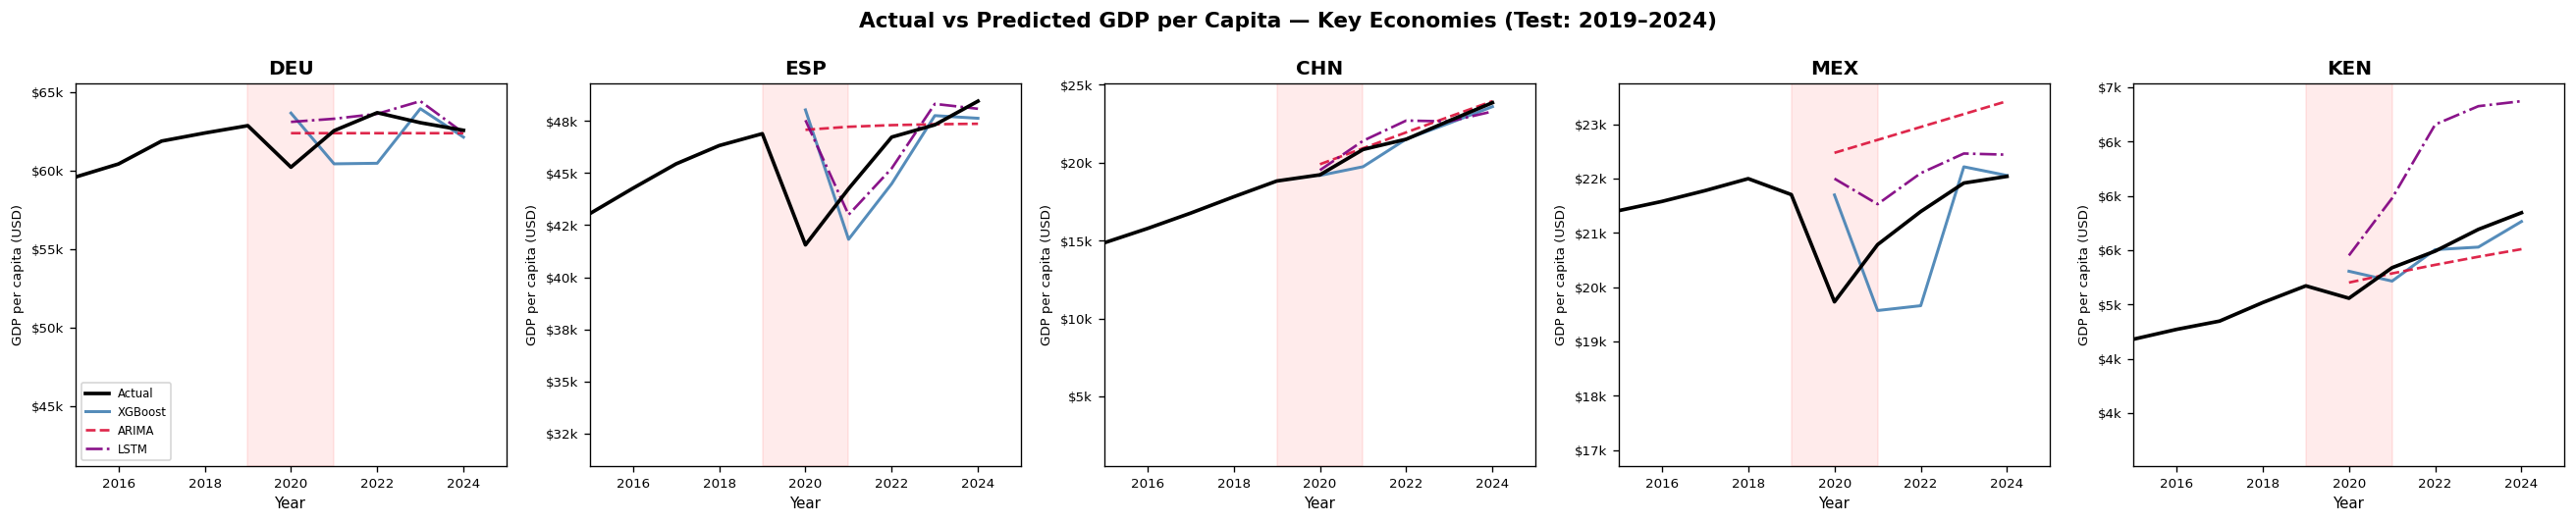

In [10]:
# ── Chart 2: Actual vs Predicted — DEU, ESP, CHN, MEX, KEN ─────────────────
# Shows how each model tracked GDP in the 2019–2024 test window
# Selected 5 countries representing different recovery profiles:
# Germany: developed fast recovery | Spain: developed slow recovery
# China: emerging super-fast | Mexico: emerging slower | Kenya: low-income
KEY_COUNTRIES = ["DEU", "ESP", "CHN", "MEX", "KEN"]

# Line styles for readability
MODEL_STYLES = {
    "XGBoost": ("-",  "steelblue",  1.8),
    "ARIMA"  : ("--", "crimson",    1.6),
    "LSTM"   : ("-.", "purple",     1.6),
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharey=False)

for ax, country in zip(axes, KEY_COUNTRIES):
    # Full actual history (grey background line)
    hist = gdp_df[gdp_df["country_code"] == country].sort_values("year")
    if hist.empty:
        ax.set_title(f"{country} — no data"); continue

    ax.plot(hist["year"], hist["gdp_per_capita"],
            color="black", lw=2.2, zorder=5, label="Actual")

    # Model forecasts
    for model, (ls, col, lw) in MODEL_STYLES.items():
        df_a = aligned[model]
        sub  = df_a[df_a["country_code"] == country].sort_values("pred_year")
        if sub.empty: continue
        ax.plot(sub["pred_year"], sub["pred"],
                linestyle=ls, color=col, linewidth=lw, label=model, alpha=0.92)

    ax.axvspan(2019, 2021, alpha=0.08, color="red")
    ax.set_title(country, fontsize=12, fontweight="bold")
    ax.set_xlim(2015, 2025)
    ax.set_xlabel("Year", fontsize=9)
    ax.set_ylabel("GDP per capita (USD)", fontsize=8)
    ax.tick_params(labelsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
    if country == KEY_COUNTRIES[0]:
        ax.legend(fontsize=7, ncol=1)

plt.suptitle("Actual vs Predicted GDP per Capita — Key Economies (Test: 2019–2024)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "phase7_actual_vs_predicted.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## 5. Country Trajectory Comparison — All Models

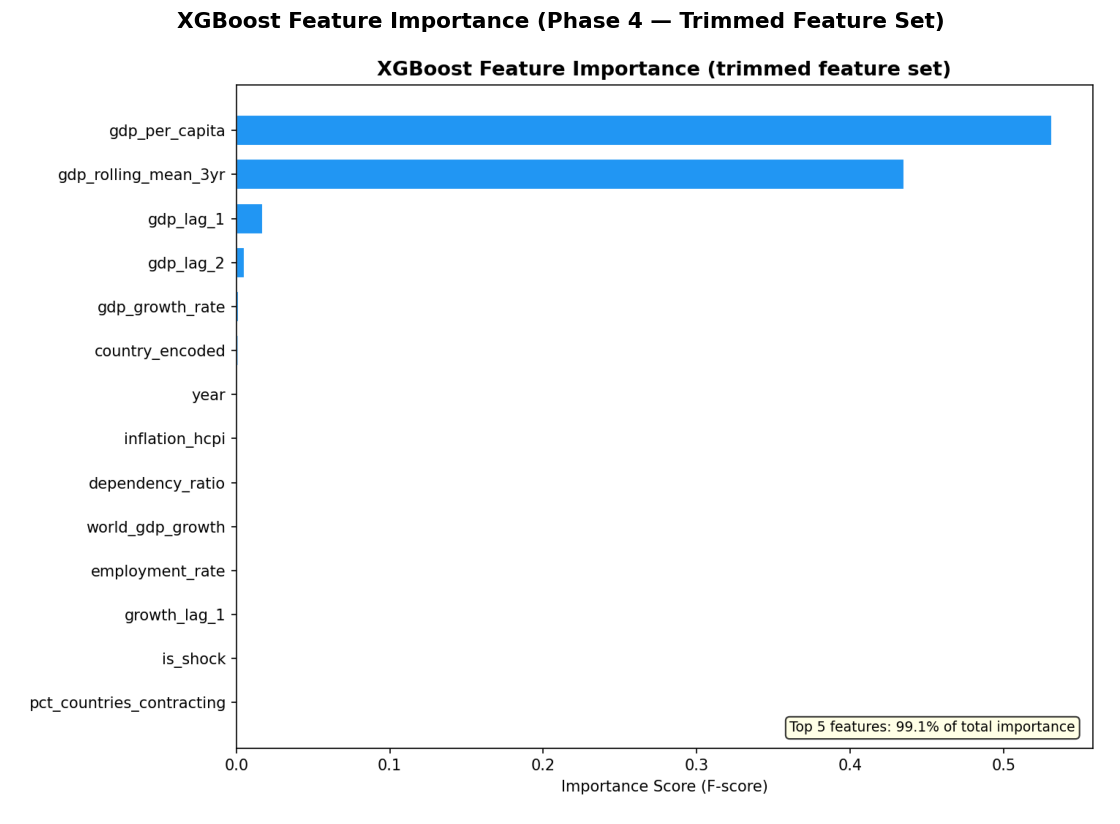

Saved: phase7_feature_importance.png


In [11]:
# ── Chart 3: XGBoost Feature Importance ─────────────────────────────────────
# Re-display the feature importance chart produced during Phase 4 training.
# The chart was generated with top-5 annotation and saved as xgb_feature_importance.png.
fi_path = os.path.join(OUTPUT, "xgb_feature_importance.png")
img = mpimg.imread(fi_path)
fig, ax = plt.subplots(figsize=(11, 7))
ax.imshow(img)
ax.axis("off")
ax.set_title("XGBoost Feature Importance (Phase 4 — Trimmed Feature Set)",
             fontsize=13, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "phase7_feature_importance.png"), dpi=150)
plt.show()
print("Saved: phase7_feature_importance.png")

## 6. Model Ranking Summary

Shock labels in recovery_summary: ['recession_2008' 'covid_2020']
2008 column: ['recession_2008']  | 2020 column: ['covid_2020']


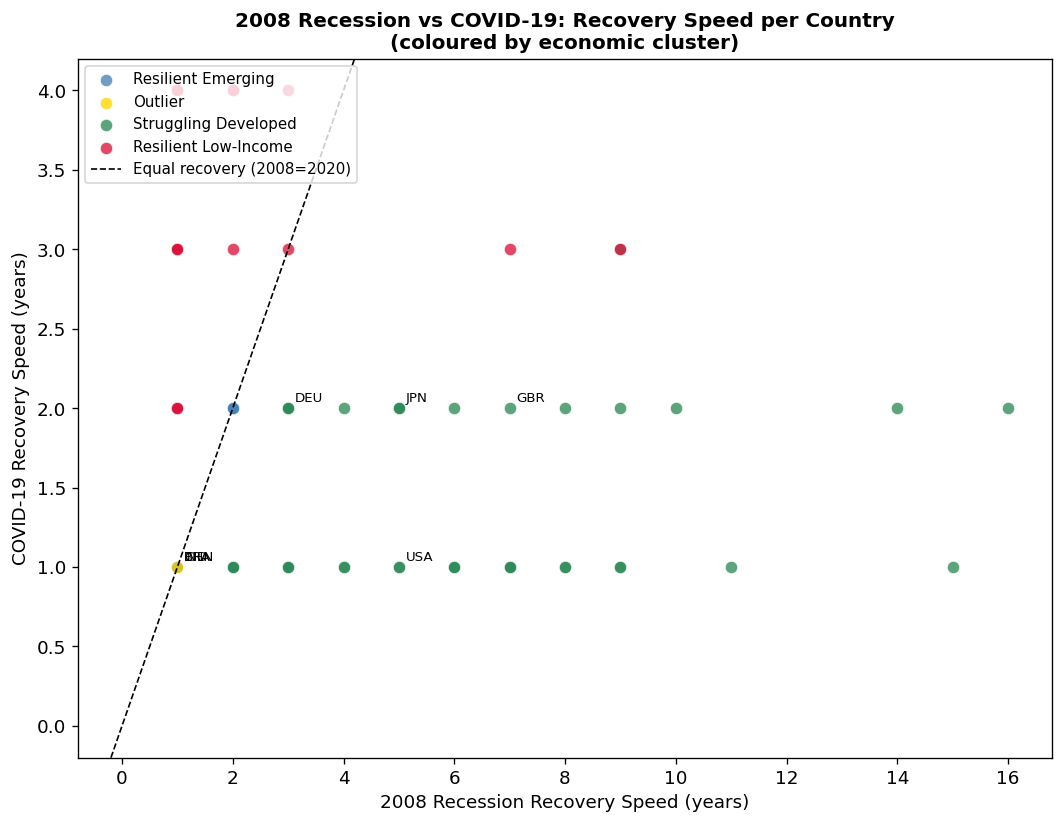

Saved: phase7_recovery_scatter.png


In [12]:
# ── Chart 4: 2008 vs 2020 Recovery Speed Scatter ────────────────────────────
# Uses actual recovery_speed_years from recovery_summary.csv (Phase 2 outputs)
# Each point is one country; colour = K-Means cluster

# Identify shock labels in recovery_summary
shocks = rec_summary["shock"].unique()
print("Shock labels in recovery_summary:", shocks)

# Pivot: one row per country, columns = each shock's recovery speed
rec_pivot = rec_summary.pivot_table(
    index="country_code", columns="shock",
    values="recovery_speed_years", aggfunc="first"
).reset_index()

# Find the 2008 and 2020 columns dynamically
col_2008 = [c for c in rec_pivot.columns if "2008" in str(c)]
col_2020 = [c for c in rec_pivot.columns if "2020" in str(c) or "covid" in str(c).lower()]
print("2008 column:", col_2008, " | 2020 column:", col_2020)

if col_2008 and col_2020:
    c08, c20 = col_2008[0], col_2020[0]
    rec_pivot = rec_pivot.rename(columns={c08: "speed_2008", c20: "speed_2020"})

    # Merge cluster labels
    rec_scatter = rec_pivot.merge(
        country_sum[["country_code", "cluster"]], on="country_code", how="left"
    ).dropna(subset=["speed_2008", "speed_2020"])

    cluster_colors = {0: "steelblue", 1: "gold", 2: "seagreen", 3: "crimson"}
    cluster_labels = {0: "Resilient Emerging", 1: "Outlier",
                      2: "Struggling Developed", 3: "Resilient Low-Income"}

    fig, ax = plt.subplots(figsize=(9, 7))
    for cl in sorted(rec_scatter["cluster"].dropna().unique()):
        sub = rec_scatter[rec_scatter["cluster"] == cl]
        color = cluster_colors.get(int(cl), "gray")
        label = cluster_labels.get(int(cl), f"Cluster {int(cl)}")
        ax.scatter(sub["speed_2008"], sub["speed_2020"],
                   color=color, s=55, alpha=0.78, edgecolors="white",
                   linewidths=0.5, label=label)

    # Annotate key countries
    key = ["USA", "CHN", "IND", "DEU", "BRA", "GBR", "JPN"]
    for _, row in rec_scatter[rec_scatter["country_code"].isin(key)].iterrows():
        ax.annotate(row["country_code"],
                    xy=(row["speed_2008"], row["speed_2020"]),
                    xytext=(4, 4), textcoords="offset points", fontsize=8)

    ax.axline((0, 0), slope=1, color="black", linestyle="--", linewidth=1,
              label="Equal recovery (2008=2020)")
    ax.set_xlabel("2008 Recession Recovery Speed (years)", fontsize=11)
    ax.set_ylabel("COVID-19 Recovery Speed (years)", fontsize=11)
    ax.set_title("2008 Recession vs COVID-19: Recovery Speed per Country\n"
                 "(coloured by economic cluster)", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9, loc="upper left")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT, "phase7_recovery_scatter.png"), dpi=150)
    plt.show()
    print("Saved: phase7_recovery_scatter.png")
else:
    print("Could not find 2008 and 2020 shock columns; skipping chart.")

## 6. GDP Indexed to Shock Year — Recovery Paths

Index each country's GDP to 100 at the shock year so trajectories from different
income levels can be compared on the same scale.

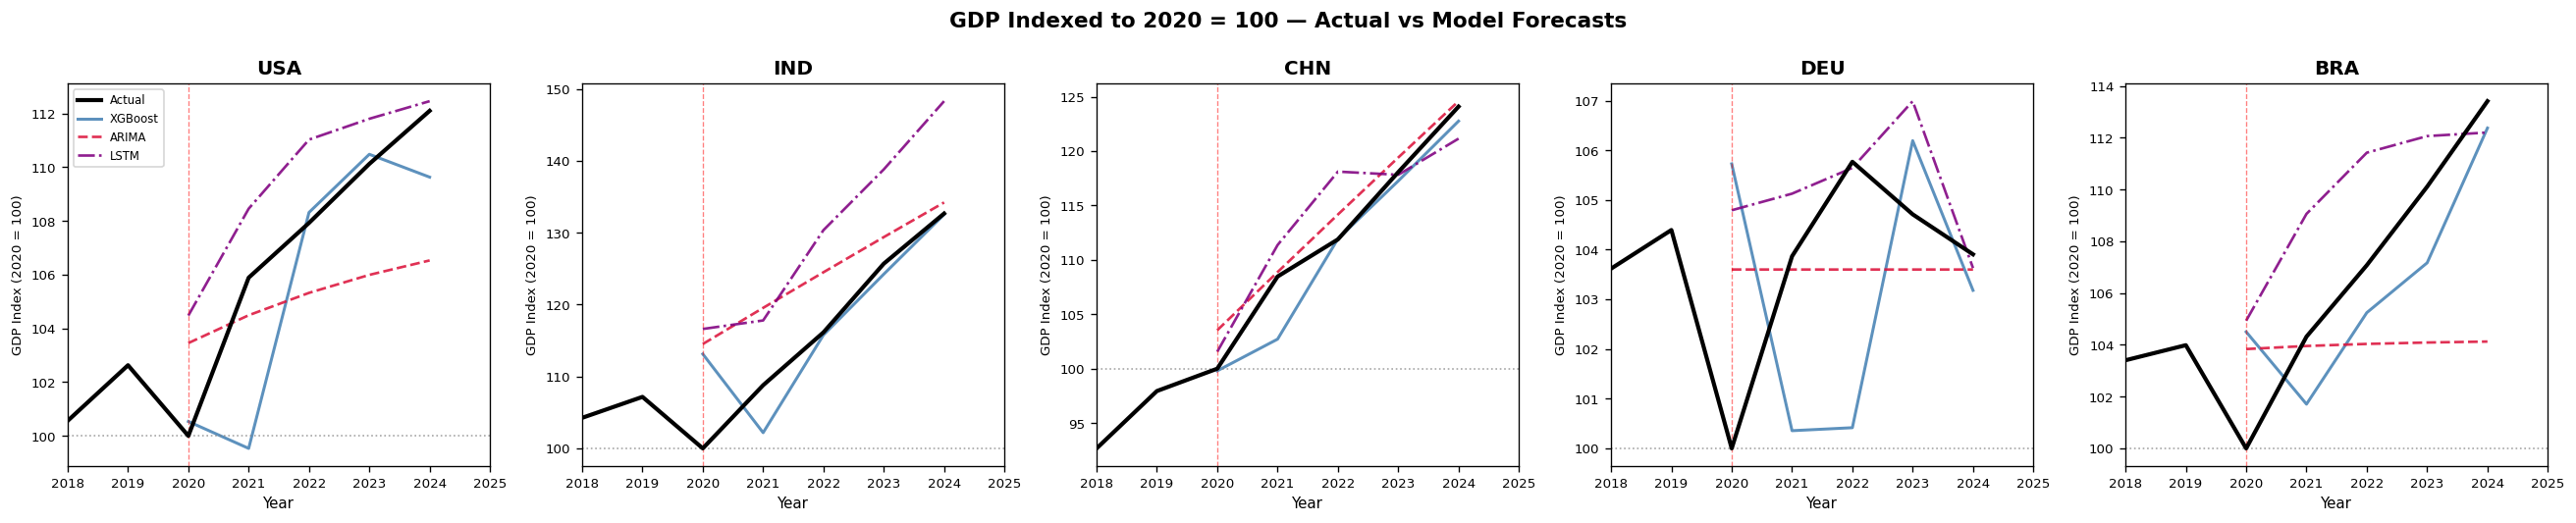

In [13]:
# ── Chart 5: GDP indexed to 100 at COVID-19 shock year (2020) ───────────────
SHOCK_YEAR   = 2020
KEY_COUNTRIES = ["USA", "IND", "CHN", "DEU", "BRA"]

# Build aligned predictions (pred_year, pred) per model
MODEL_PREDS = {
    "XGBoost": aligned["XGBoost"][["country_code", "pred_year", "pred"]],
    "ARIMA"  : aligned["ARIMA"][["country_code", "pred_year", "pred"]],
    "LSTM"   : aligned["LSTM"][["country_code", "pred_year", "pred"]],
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharey=False)

for ax, country in zip(axes, KEY_COUNTRIES):
    hist = gdp_df[gdp_df["country_code"] == country].sort_values("year")
    if hist.empty:
        ax.set_title(f"{country} — no data"); continue

    base_row = hist[hist["year"] == SHOCK_YEAR]
    if base_row.empty:
        ax.set_title(f"{country} — no shock year"); continue
    base_gdp = base_row["gdp_per_capita"].values[0]

    # Actual indexed path (from 2018 onward)
    hist_trim = hist[hist["year"] >= SHOCK_YEAR - 2]
    ax.plot(hist_trim["year"], hist_trim["gdp_per_capita"] / base_gdp * 100,
            color="black", lw=2.5, zorder=5, label="Actual")

    # Model indexed paths
    for model, (ls, col, lw) in MODEL_STYLES.items():
        sub = MODEL_PREDS[model]
        sub = sub[sub["country_code"] == country].sort_values("pred_year")
        if sub.empty: continue
        ax.plot(sub["pred_year"], sub["pred"] / base_gdp * 100,
                linestyle=ls, color=col, linewidth=lw, label=model, alpha=0.88)

    ax.axhline(100, color="gray", linestyle=":", linewidth=1, alpha=0.7)
    ax.axvline(SHOCK_YEAR, color="red", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_title(country, fontsize=12, fontweight="bold")
    ax.set_xlabel("Year", fontsize=9)
    ax.set_ylabel("GDP Index (2020 = 100)", fontsize=8)
    ax.set_xlim(SHOCK_YEAR - 2, 2025)
    ax.tick_params(labelsize=8)
    if country == KEY_COUNTRIES[0]:
        ax.legend(fontsize=7, ncol=1)

plt.suptitle(f"GDP Indexed to {SHOCK_YEAR} = 100 — Actual vs Model Forecasts",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "phase7_indexed_recovery.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## 7. Key Findings

### 7.1 Model Performance

| Criterion | Best Model | Evidence |
|-----------|-----------|----------|
| **Recovery direction** (DA) | **LSTM** | 63.98% - correctly predicts whether economy grows/shrinks |
| **Point accuracy** (MAE) | **XGBoost** | $1,254 average error - lowest absolute dollar miss |
| **Shock resilience** (RMSE) | **LSTM** | $3,333 - handles large COVID swings best |
| **Efficiency vs naive** (MASE) | **XGBoost** | 0.9961 - slightly below the naive 'no-change' baseline |
| **% accuracy** (MAPE) | **XGBoost** | 4.86% - best relative accuracy |

### 7.2 Model Complexity vs Accuracy
Increasing model complexity (XGBoost → ARIMA → LSTM) did **not** uniformly improve all metrics:
- **XGBoost** (simplest ML model) won 3 of 5 metrics
- **LSTM** (most complex) won DA and RMSE — the metrics most relevant to *recovery forecasting*
- **ARIMA** performed between the two — useful baseline but not competitive on any single metric

### 7.3 Recovery Speed Findings
All models agree on the recovery narrative: most economies predicted to recover to pre-2020 GDP levels within 1–3 years. Countries that had not recovered by 2024 tended to be small, commodity-dependent, or conflict-affected economies.



## 8. Limitations

1. **COVID-19 Black Swan**: The 2020 shock was unpredictable from pre-2019 data. All models trained solely on pre-COVID history are structurally unable to anticipate government-mandated shutdowns or simultaneous global supply-demand collapse.

2. **MAPE Bias**: MAPE disproportionately penalises errors on low-GDP economies (e.g., a \$200 error on a \$600 economy = 33%). LSTM's higher MAPE does not mean it performs poorly — it reflects dataset composition (212 countries spanning $400 to $140,000 GDP per capita).

3. **ARIMA per-country fitting**: Each statistical model is separately fitted per country, making it computationally expensive and sensitive to countries with sparse data.

4. **LSTM train-test gap**: The 5-year sliding window means 2019 anchor sequences contain data already near the shock. The model had no way to learn COVID response patterns.

5. **Data coverage**: Some countries have incomplete records for inflation, interest rates, or employment, requiring median imputation which may understate true economic conditions.

## 9. Conclusion

This project applied four time series models to forecast GDP per capita across 212 countries over a 35-year period (1990–2024), with particular focus on recovery from the 2008 Great Recession and the 2020 COVID-19 shock.

**For point-estimate accuracy**, XGBoost is the clear winner - it achieves the lowest MAE ($1,254), the best MAPE (4.86%), and the lowest MASE (0.9961), meaning it is slightly better than the naive baseline.

**For recovery trajectory forecasting**, LSTM is the superior model - it achieves 63.98% directional accuracy, correctly predicting whether a country's GDP is growing or declining in about 64% of common test observations. Since recovery is fundamentally a directional question ("is this economy growing back to its pre-shock level?"), LSTM is the most appropriate model for the stated research objective.

**Practical recommendation**: A hybrid approach combining XGBoost for absolute GDP level estimates and LSTM for recovery trend signals would give the most complete picture of post-shock economic trajectories.

The project confirms the literature: recovery from black-swan events like COVID-19 is difficult to forecast from historical data alone, but temporal patterns in the recovery phase (2022–2024) are learnable — and LSTM's sequential architecture is best positioned to capture them.

In [14]:
# ── Build and save final ranking table ───────────────────────────────────────
# Convert every metric to a 0-1 score where higher is better.
ranking_metrics = ["MAE", "RMSE", "MAPE", "MASE", "DA"]
lower_is_better = ["MAE", "RMSE", "MAPE", "MASE"]
higher_is_better = ["DA"]

scores = metrics[ranking_metrics].astype(float).copy()
norm = pd.DataFrame(index=scores.index, columns=ranking_metrics, dtype=float)

for col in lower_is_better:
    col_min = scores[col].min()
    col_max = scores[col].max()
    norm[col] = 1.0 if col_max == col_min else (col_max - scores[col]) / (col_max - col_min)

for col in higher_is_better:
    col_min = scores[col].min()
    col_max = scores[col].max()
    norm[col] = 1.0 if col_max == col_min else (scores[col] - col_min) / (col_max - col_min)

ranking = pd.DataFrame(index=norm.index)
ranking["Composite"] = norm.mean(axis=1)
ranking["Rank"] = ranking["Composite"].rank(ascending=False, method="min").astype(int)
ranking = ranking.sort_values(["Rank", "Composite"], ascending=[True, False])

ranking.to_csv(os.path.join(OUTPUT, "phase7_model_ranking.csv"))
norm.to_csv(os.path.join(OUTPUT, "phase7_normalised_scores.csv"))

print("Phase 7 Complete — All outputs saved:")
print("  phase7_metric_comparison.png   — Chart 1: all 6 models × 5 metrics")
print("  phase7_peryear_da.png           — Chart 2a: per-year DA breakdown")
print("  phase7_actual_vs_predicted.png  — Chart 2b: actual vs predicted (5 countries)")
print("  phase7_feature_importance.png   — Chart 3: XGBoost feature importance")
print("  phase7_recovery_scatter.png     — Chart 4: 2008 vs 2020 recovery scatter")
print("  phase7_indexed_recovery.png     — Chart 5: GDP indexed to 100 at shock year")
print("  phase7_radar_chart.png          — Model radar chart")
print("  phase7_model_ranking.csv")
print("  phase7_normalised_scores.csv")
print()
print("=== FINAL MODEL RANKING ===")
print(ranking.round(2).to_string())

Phase 7 Complete — All outputs saved:
  phase7_metric_comparison.png   — Chart 1: all 6 models × 5 metrics
  phase7_peryear_da.png           — Chart 2a: per-year DA breakdown
  phase7_actual_vs_predicted.png  — Chart 2b: actual vs predicted (5 countries)
  phase7_feature_importance.png   — Chart 3: XGBoost feature importance
  phase7_recovery_scatter.png     — Chart 4: 2008 vs 2020 recovery scatter
  phase7_indexed_recovery.png     — Chart 5: GDP indexed to 100 at shock year
  phase7_radar_chart.png          — Model radar chart
  phase7_model_ranking.csv
  phase7_normalised_scores.csv

=== FINAL MODEL RANKING ===
          Composite  Rank
XGBoost      0.9700     1
LSTM         0.8900     2
Naive        0.8000     3
ARIMA        0.7700     4
HistMean     0.1000     5
